# **Projeto: Previsão de Intenção de Compra de Clientes em Loja Web**

**Descrição do Projeto**

Neste projeto, nosso objetivo é criar um sistema inteligente para antecipar a intenção de compra dos clientes em um site de e-commerce. Imagine poder prever quais clientes têm maior probabilidade de realizar compras online, com base em suas características e comportamentos passados. Essa capacidade de prever a intenção de compra não só aprimorará a experiência do cliente, mas também permitirá que a empresa direcione seus esforços de marketing de forma mais eficaz.

**Objetivo**

Queremos desenvolver um modelo preditivo capaz de analisar os padrões de comportamento dos clientes e identificar sinais que indicam a propensão deles para realizar compras no site da empresa. Para isso, vamos usar uma base de dados que contém informações detalhadas sobre os clientes, incluindo:

Dados demográficos (idade, renda, etc.)

Informações sobre compras anteriores



# Base de dados:

Year_Birth: Ano de nascimento do cliente.

Education: Nível de escolaridade do cliente.

Marital_Status: Estado civil do cliente.

Income: Renda anual da família do cliente.

Kidhome: Número de crianças na casa do cliente.

Recency: Número de dias desde a última compra do cliente.

Complain: 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário.

MntWines: Valor gasto em vinhos nos últimos 2 anos.

MntFruits: Valor gasto em frutas nos últimos 2 anos.

MntMeatProducts: Valor gasto em carnes nos últimos 2 anos.

MntFishProducts: Valor gasto em peixes nos últimos 2 anos.

MntSweetProducts: Valor gasto em doces nos últimos 2 anos.

MntGoldProds: Valor gasto em produtos de ouro nos últimos 2 anos.

NumDealsPurchases: Número de compras feitas com desconto

NumStorePurchases: Número de compras feitas diretamente nas lojas.

NumWebVisitsMonth: Número de visitas ao site da empresa no último mês.






**WebPurchases: Número de compras feitas pelo site da empresa.**

# ETAPA 1:

**Preparação dos Dados**

**Exploração e Limpeza:** Analisar e limpar os dados para garantir que estejam prontos para a modelagem.

**Análise:** Construa uma storytelling com gráficos, analisando e retirando insights das informações.

Foi feita uma análise inicial dos dados e identificada a presença de valores nulos na coluna Income. Como esses registros representavam apenas 1,07% do total, optou-se por removê-los, pois o impacto no conjunto de dados é mínimo.

Também foram encontradas duas colunas do tipo object, mas elas não foram tratadas neste momento, já que serão convertidas na próxima etapa para um formato numérico adequado ao modelo.

Em relação aos outliers, as colunas MntMeatProducts, MntFishProducts, MntFruits, MntSweetProducts e MntGoldProds apresentaram valores extremos, que foram tratados com a substituição pela mediana. Já nas colunas MntWines, Year_Birth e Income, os outliers representavam menos de 2% dos dados, então foi feita a remoção desses registros.

Cerca de 50% dos clientes realizam compras pelo site. Aproximadamente 40% são casados, e em torno de 80% possuem alto nível de escolaridade (graduação, mestrado ou doutorado). Observa-se ainda que o público que mais compra online é formado principalmente por clientes casados e com nível superior.

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


In [79]:
df = pd.read_csv('marketing_campaign.csv', delimiter=';')
(df.isnull().sum() / len(df)) * 100

Year_Birth           0.000000
Education            0.000000
Marital_Status       0.000000
Income               1.071429
Kidhome              0.000000
Recency              0.000000
MntWines             0.000000
MntFruits            0.000000
MntMeatProducts      0.000000
MntFishProducts      0.000000
MntSweetProducts     0.000000
MntGoldProds         0.000000
NumStorePurchases    0.000000
NumWebVisitsMonth    0.000000
Complain             0.000000
WebPurchases         0.000000
dtype: float64

In [80]:
df = df.dropna(subset=['Income'])

In [81]:
df.isnull().sum()

Year_Birth           0
Education            0
Marital_Status       0
Income               0
Kidhome              0
Recency              0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
NumStorePurchases    0
NumWebVisitsMonth    0
Complain             0
WebPurchases         0
dtype: int64

In [82]:
df.dtypes

Year_Birth             int64
Education             object
Marital_Status        object
Income               float64
Kidhome                int64
Recency                int64
MntWines               int64
MntFruits              int64
MntMeatProducts        int64
MntFishProducts        int64
MntSweetProducts       int64
MntGoldProds           int64
NumStorePurchases      int64
NumWebVisitsMonth      int64
Complain               int64
WebPurchases           int64
dtype: object

In [83]:
df

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,46,709,43,182,42,118,247,4,5,0,1
2236,1946,PhD,Together,64014.0,2,56,406,0,30,0,0,8,5,7,0,1
2237,1981,Graduation,Divorced,56981.0,0,91,908,48,217,32,12,24,13,6,0,0
2238,1956,Master,Together,69245.0,0,8,428,30,214,80,30,61,10,3,0,1


In [84]:
df.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,1968.820397,52247.251354,0.441787,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,5.800993,5.319043,0.009477,0.504513
std,11.985554,25173.076661,0.536896,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,3.250785,2.425359,0.096907,0.500092
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51381.500000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68522.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,13.000000,20.000000,1.000000,1.000000


In [85]:
df[df['Year_Birth'] < 1940]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
192,1900,2n Cycle,Divorced,36640.0,1,99,15,6,8,7,4,25,2,5,1,0
239,1893,2n Cycle,Single,60182.0,0,23,8,0,5,7,0,2,2,4,0,0
339,1899,PhD,Together,83532.0,0,36,755,144,562,104,64,224,4,1,0,1


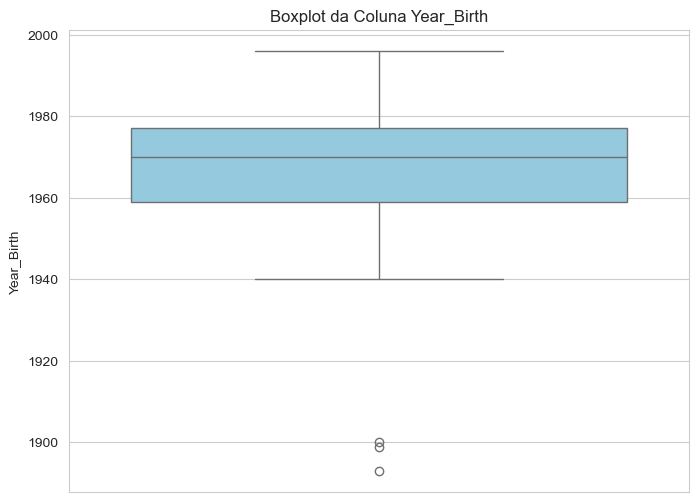

In [86]:
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='Year_Birth', color= 'skyblue')
plt.title('Boxplot da Coluna Year_Birth')
plt.ylabel('Year_Birth')
plt.show()

In [87]:
Q1_year = df['Year_Birth'].quantile(0.25)
Q3_year = df['Year_Birth'].quantile(0.75)

IQR_year = Q3_year - Q1_year

limite_superior_year = Q3_year + 1.5 * IQR_year
limite_inferior_year = Q1_year - 1.5 * IQR_year

In [88]:
df = df[(df['Year_Birth'] >= limite_inferior_year) & 
        (df['Year_Birth'] <= limite_superior_year)]
df.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000
mean,1968.917307,52236.581563,0.441934,49.007682,305.153638,26.323995,166.962494,37.635337,27.034794,43.911432,5.805242,5.321735,0.009038,0.504745
std,11.700216,25178.603047,0.536965,28.941864,337.305490,39.735932,224.226178,54.763278,41.085433,51.699746,3.250752,2.425092,0.094657,0.500090
min,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35246.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51373.000000,0.000000,49.000000,175.000000,8.000000,68.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68487.000000,1.000000,74.000000,505.000000,33.000000,232.000000,50.000000,33.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,13.000000,20.000000,1.000000,1.000000


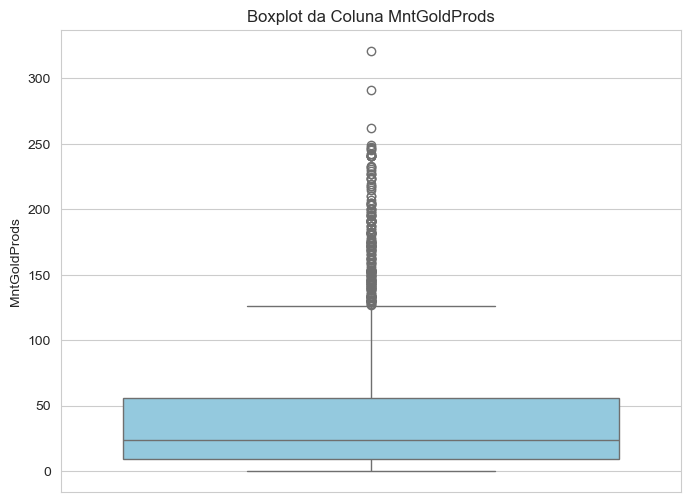

In [89]:
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='MntGoldProds', color= 'skyblue')
plt.title('Boxplot da Coluna MntGoldProds')
plt.ylabel('MntGoldProds')
plt.show()

In [90]:
Q1 = df['MntGoldProds'].quantile(0.25)
Q3 = df['MntGoldProds'].quantile(0.75)

IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

In [91]:
(df['MntGoldProds'] > limite_superior).mean() * 100

np.float64(9.21825576140985)

In [92]:
df.loc[df['MntGoldProds'] > limite_superior, 'MntGoldProds'] =  df['MntGoldProds'].median()
df.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000
mean,1968.917307,52236.581563,0.441934,49.007682,305.153638,26.323995,166.962494,37.635337,27.034794,30.032987,5.805242,5.321735,0.009038,0.504745
std,11.700216,25178.603047,0.536965,28.941864,337.305490,39.735932,224.226178,54.763278,41.085433,28.678320,3.250752,2.425092,0.094657,0.500090
min,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35246.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51373.000000,0.000000,49.000000,175.000000,8.000000,68.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68487.000000,1.000000,74.000000,505.000000,33.000000,232.000000,50.000000,33.000000,41.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,126.000000,13.000000,20.000000,1.000000,1.000000


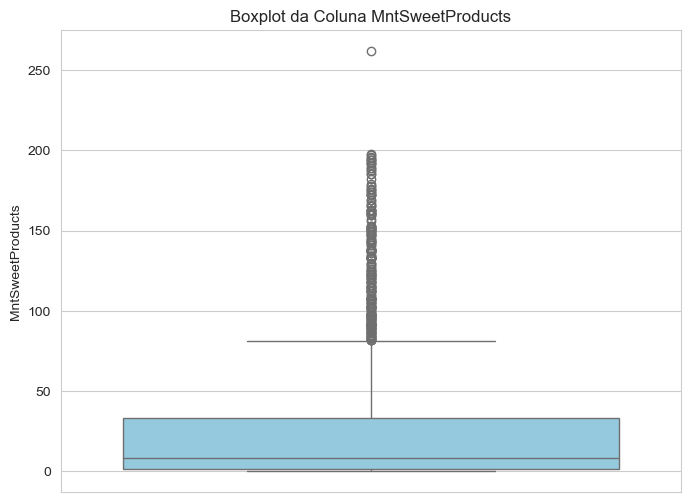

In [93]:
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='MntSweetProducts', color= 'skyblue')
plt.title('Boxplot da Coluna MntSweetProducts')
plt.ylabel('MntSweetProducts')
plt.show()

In [94]:

Q1_mnt_sweet = df['MntSweetProducts'].quantile(0.25)
Q3_mnt_sweet = df['MntSweetProducts'].quantile(0.75)

IQR_mnt_sweet = Q3_mnt_sweet - Q1_mnt_sweet

limite_superior_mnt_sweet = Q3_mnt_sweet + 1.5 * IQR_mnt_sweet
limite_inferior_mnt_sweet = Q1_mnt_sweet - 1.5 * IQR_mnt_sweet

In [95]:
(df['MntSweetProducts'] > limite_superior_mnt_sweet).mean() * 100

np.float64(11.116131947582467)

In [96]:
df.loc[df['MntSweetProducts'] > limite_superior_mnt_sweet, 'MntSweetProducts'] =  df['MntSweetProducts'].median()
df.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000
mean,1968.917307,52236.581563,0.441934,49.007682,305.153638,26.323995,166.962494,37.635337,13.835066,30.032987,5.805242,5.321735,0.009038,0.504745
std,11.700216,25178.603047,0.536965,28.941864,337.305490,39.735932,224.226178,54.763278,18.062139,28.678320,3.250752,2.425092,0.094657,0.500090
min,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35246.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51373.000000,0.000000,49.000000,175.000000,8.000000,68.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68487.000000,1.000000,74.000000,505.000000,33.000000,232.000000,50.000000,18.000000,41.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,81.000000,126.000000,13.000000,20.000000,1.000000,1.000000


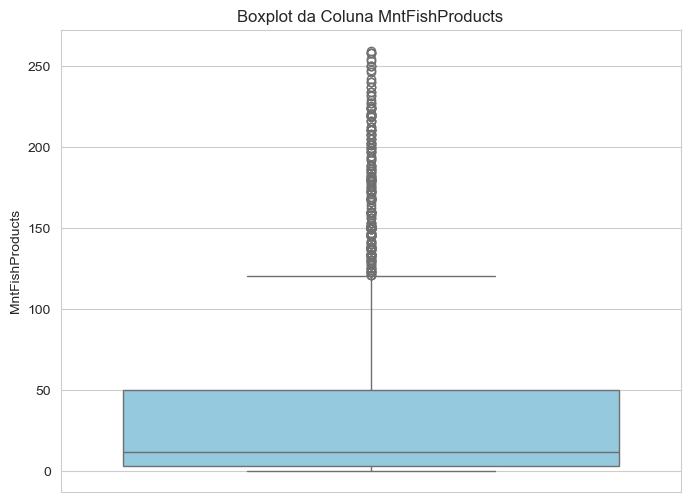

In [97]:
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='MntFishProducts', color= 'skyblue')
plt.title('Boxplot da Coluna MntFishProducts')
plt.ylabel('MntFishProducts')
plt.show()

In [98]:
Q1_mnt_fish = df['MntFishProducts'].quantile(0.25)
Q3_mnt_fish = df['MntFishProducts'].quantile(0.75)

IQR_mnt_fish = Q3_mnt_fish - Q1_mnt_fish

limite_superior_mnt_fish = Q3_mnt_fish + 1.5 * IQR_mnt_fish
limite_inferior_mnt_fish = Q1_mnt_fish - 1.5 * IQR_mnt_fish

In [99]:
(df['MntFishProducts'] > limite_superior_mnt_fish).mean() * 100

np.float64(10.031631269769543)

In [100]:
df.loc[df['MntFishProducts'] > limite_superior_mnt_fish, 'MntFishProducts'] =  df['MntFishProducts'].median()
df.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000
mean,1968.917307,52236.581563,0.441934,49.007682,305.153638,26.323995,166.962494,21.295075,13.835066,30.032987,5.805242,5.321735,0.009038,0.504745
std,11.700216,25178.603047,0.536965,28.941864,337.305490,39.735932,224.226178,27.782043,18.062139,28.678320,3.250752,2.425092,0.094657,0.500090
min,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35246.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51373.000000,0.000000,49.000000,175.000000,8.000000,68.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68487.000000,1.000000,74.000000,505.000000,33.000000,232.000000,28.000000,18.000000,41.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,120.000000,81.000000,126.000000,13.000000,20.000000,1.000000,1.000000


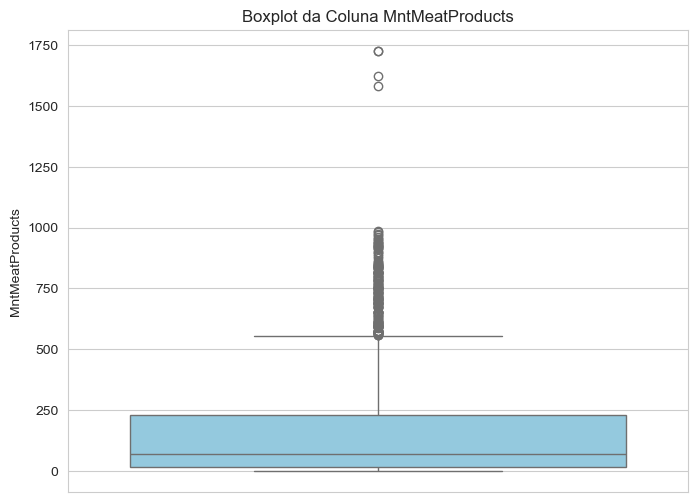

In [101]:
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='MntMeatProducts', color= 'skyblue')
plt.title('Boxplot da Coluna MntMeatProducts')
plt.ylabel('MntMeatProducts')
plt.show()

In [102]:
Q1_mnt_meat = df['MntMeatProducts'].quantile(0.25)
Q3_mnt_meat = df['MntMeatProducts'].quantile(0.75)

IQR_mnt_meat = Q3_mnt_meat - Q1_mnt_meat

limite_superior_mnt_meat = Q3_mnt_meat + 1.5 * IQR_mnt_meat
limite_inferior_mnt_meat = Q1_mnt_meat - 1.5 * IQR_mnt_meat

In [103]:
(df['MntMeatProducts'] > limite_superior_mnt_meat).mean() * 100

np.float64(7.817442385901491)

In [104]:
df.loc[df['MntMeatProducts'] > limite_superior_mnt_meat, 'MntMeatProducts'] =  df['MntMeatProducts'].median()
df.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000
mean,1968.917307,52236.581563,0.441934,49.007682,305.153638,26.323995,113.018075,21.295075,13.835066,30.032987,5.805242,5.321735,0.009038,0.504745
std,11.700216,25178.603047,0.536965,28.941864,337.305490,39.735932,134.998790,27.782043,18.062139,28.678320,3.250752,2.425092,0.094657,0.500090
min,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35246.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51373.000000,0.000000,49.000000,175.000000,8.000000,68.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68487.000000,1.000000,74.000000,505.000000,33.000000,153.000000,28.000000,18.000000,41.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,555.000000,120.000000,81.000000,126.000000,13.000000,20.000000,1.000000,1.000000


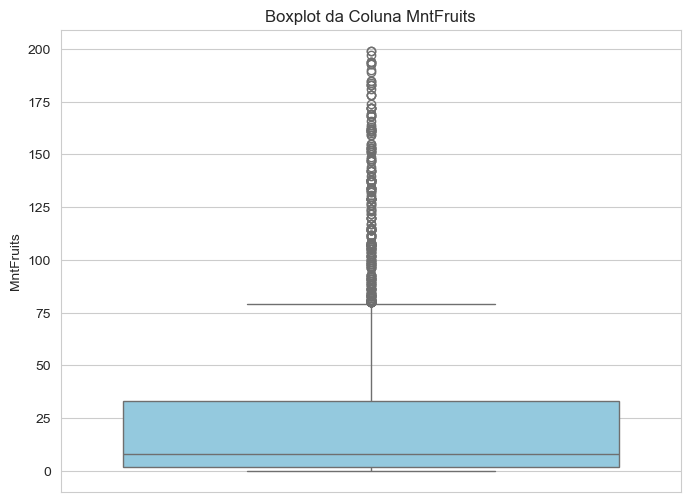

In [105]:
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='MntFruits', color= 'skyblue')
plt.title('Boxplot da Coluna MntFruits')
plt.ylabel('MntFruits')
plt.show()

In [106]:
Q1_mnt_fruits = df['MntFruits'].quantile(0.25)
Q3_mnt_fruits = df['MntFruits'].quantile(0.75)

IQR_mnt_fruits = Q3_mnt_fruits - Q1_mnt_fruits

limite_superior_mnt_fruits = Q3_mnt_fruits + 1.5 * IQR_mnt_fruits
limite_inferior_mnt_fruits = Q1_mnt_fruits - 1.5 * IQR_mnt_fruits

In [107]:
(df['MntFruits'] > limite_superior_mnt_fruits).mean() * 100

np.float64(11.070944419340261)

In [108]:
df.loc[df['MntFruits'] > limite_superior_mnt_fruits, 'MntFruits'] =  df['MntFruits'].median()
df.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000
mean,1968.917307,52236.581563,0.441934,49.007682,305.153638,13.643922,113.018075,21.295075,13.835066,30.032987,5.805242,5.321735,0.009038,0.504745
std,11.700216,25178.603047,0.536965,28.941864,337.305490,17.603420,134.998790,27.782043,18.062139,28.678320,3.250752,2.425092,0.094657,0.500090
min,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35246.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51373.000000,0.000000,49.000000,175.000000,8.000000,68.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68487.000000,1.000000,74.000000,505.000000,18.000000,153.000000,28.000000,18.000000,41.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,79.000000,555.000000,120.000000,81.000000,126.000000,13.000000,20.000000,1.000000,1.000000


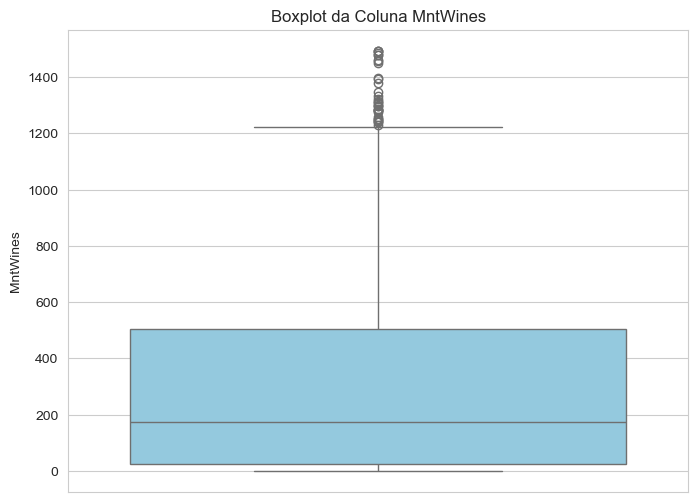

In [109]:
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='MntWines', color= 'skyblue')
plt.title('Boxplot da Coluna MntWines')
plt.ylabel('MntWines')
plt.show()

In [110]:
Q1_mnt_wines = df['MntWines'].quantile(0.25)
Q3_mnt_wines = df['MntWines'].quantile(0.75)

IQR_mnt_wines = Q3_mnt_wines - Q1_mnt_wines

limite_superior_mnt_wines = Q3_mnt_wines + 1.5 * IQR_mnt_wines
limite_inferior_mnt_wines = Q1_mnt_wines - 1.5 * IQR_mnt_wines

In [111]:
(df['MntWines'] > limite_superior_mnt_wines).mean() * 100

np.float64(1.5815634884771803)

In [112]:
df = df[(df['MntWines'] >= limite_inferior_mnt_wines) & 
        (df['MntWines'] <= limite_superior_mnt_wines)]
df.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2178.000000,2178.000000,2178.000000,2178.000000,2178.000000,2178.000000,2178.000000,2178.000000,2178.000000,2178.000000,2178.000000,2178.000000,2178.000000,2178.000000
mean,1968.983471,51801.050046,0.448118,49.021579,288.497245,13.575298,110.896235,20.947658,13.669881,30.041781,5.778237,5.335629,0.009183,0.499541
std,11.646363,25113.647964,0.538221,28.933612,312.933303,17.616443,133.780919,27.556982,17.968349,28.765643,3.254754,2.426282,0.095408,0.500115
min,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1960.000000,34936.500000,0.000000,24.000000,23.000000,2.000000,15.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,50920.500000,0.000000,49.000000,171.000000,8.000000,65.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,0.000000
75%,1977.000000,67546.000000,1.000000,74.000000,486.750000,17.000000,144.000000,26.000000,17.000000,41.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1224.000000,79.000000,555.000000,120.000000,81.000000,126.000000,13.000000,20.000000,1.000000,1.000000


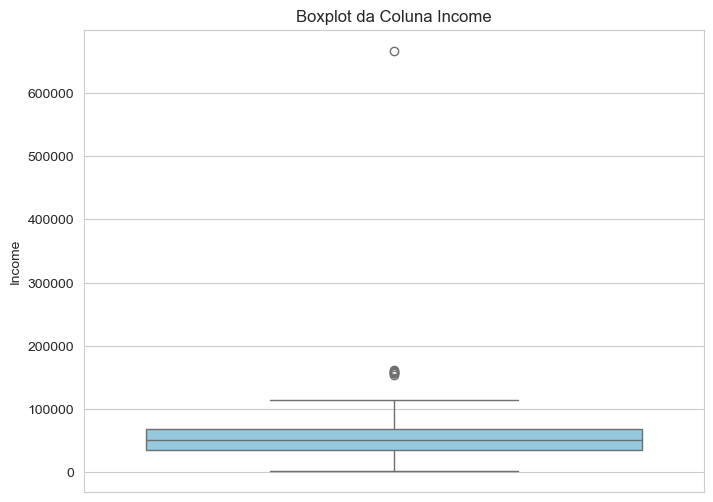

In [113]:
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='Income', color= 'skyblue')
plt.title('Boxplot da Coluna Income')
plt.ylabel('Income')
plt.show()

In [114]:
Q1_income = df['Income'].quantile(0.25)
Q3_income = df['Income'].quantile(0.75)

IQR_income = Q3_income - Q1_income

limite_superior_income = Q3_income + 1.5 * IQR_income
limite_inferior_income = Q1_income - 1.5 * IQR_income

In [115]:
(df['Income'] > limite_superior_income).mean() * 100

np.float64(0.3673094582185491)

In [116]:
df = df[(df['Income'] >= limite_inferior_income) & 
        (df['Income'] <= limite_superior_income)]
df.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2170.000000,2170.000000,2170.000000,2170.000000,2170.000000,2170.000000,2170.000000,2170.000000,2170.000000,2170.000000,2170.000000,2170.000000,2170.000000,2170.000000
mean,1968.970507,51175.046544,0.448387,49.023041,289.463134,13.608756,111.189862,21.009217,13.715668,30.138710,5.796774,5.351152,0.009217,0.501382
std,11.651939,20540.017610,0.538392,28.923667,313.099456,17.636366,133.928195,27.587188,17.985517,28.773253,3.245835,2.414458,0.095582,0.500113
min,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1960.000000,34920.750000,0.000000,24.000000,23.000000,2.000000,15.000000,3.000000,1.000000,9.000000,3.000000,3.250000,0.000000,0.000000
50%,1970.000000,50733.000000,0.000000,49.000000,172.000000,8.000000,65.500000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,67442.000000,1.000000,74.000000,488.750000,17.000000,146.500000,26.000000,17.000000,41.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,113734.000000,2.000000,99.000000,1224.000000,79.000000,555.000000,120.000000,81.000000,126.000000,13.000000,20.000000,1.000000,1.000000


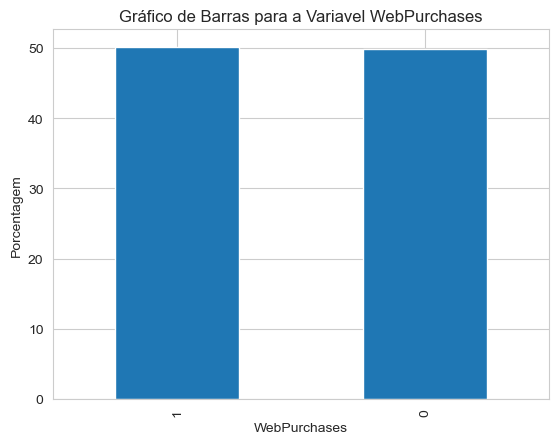

In [117]:
#contagem da coluna webpurchases
contagem_web = df['WebPurchases'].value_counts()

porcentagem_web = (contagem_web/ contagem_web.sum()) * 100
ax = porcentagem_web.plot(kind='bar')
plt.title('Gráfico de Barras para a Variavel WebPurchases')
plt.xlabel('WebPurchases')
plt.ylabel('Porcentagem')
plt.show()

In [118]:
df['Marital_Status'].value_counts()

Marital_Status
Married     840
Together    558
Single      463
Divorced    228
Widow        74
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [119]:
df = df[df['Marital_Status'] != 'Absurd']

In [120]:
marital_mapping = {
    'Single': 'Single', 
    'Together': 'Together',
    'Married': 'Married', 
    'Divorced': 'Divorced',
    'Widow': 'Widow',
    'Alone': 'Single',
    'YOLO': 'Single'
    }
df['Marital_Status'] = df['Marital_Status'].replace(marital_mapping)

In [121]:
df['Marital_Status'].value_counts()

Marital_Status
Married     840
Together    558
Single      468
Divorced    228
Widow        74
Name: count, dtype: int64

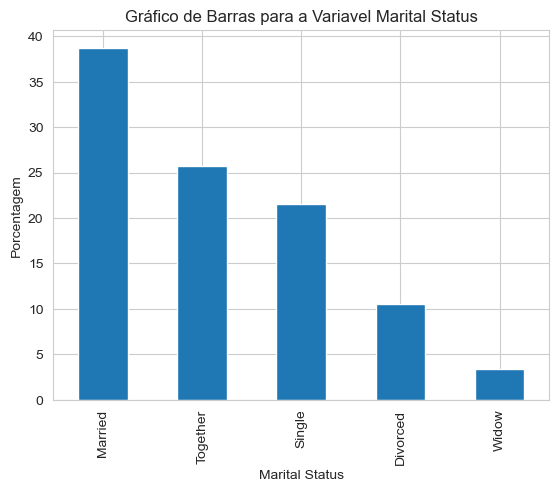

In [122]:
#contagem da coluna marital
contagem_marital = df['Marital_Status'].value_counts()

porcentagem_marital = (contagem_marital/ contagem_marital.sum()) * 100
ax = porcentagem_marital.plot(kind='bar')
plt.title('Gráfico de Barras para a Variavel Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Porcentagem')
plt.show()

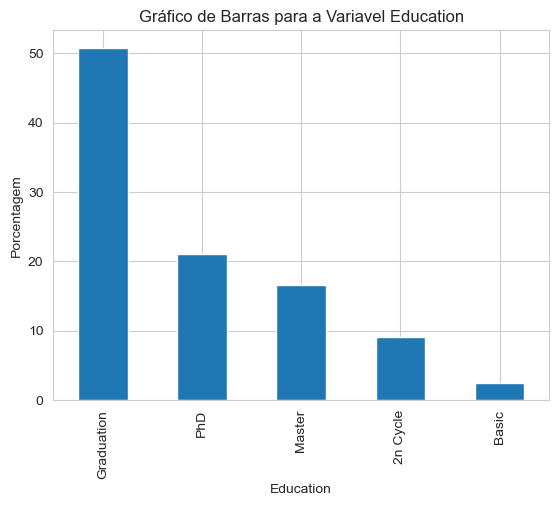

In [123]:
#contagem da coluna marital
contagem_education = df['Education'].value_counts()

porcentagem_education = (contagem_education/ contagem_education.sum()) * 100
ax = porcentagem_education.plot(kind='bar')
plt.title('Gráfico de Barras para a Variavel Education')
plt.xlabel('Education')
plt.ylabel('Porcentagem')
plt.show()

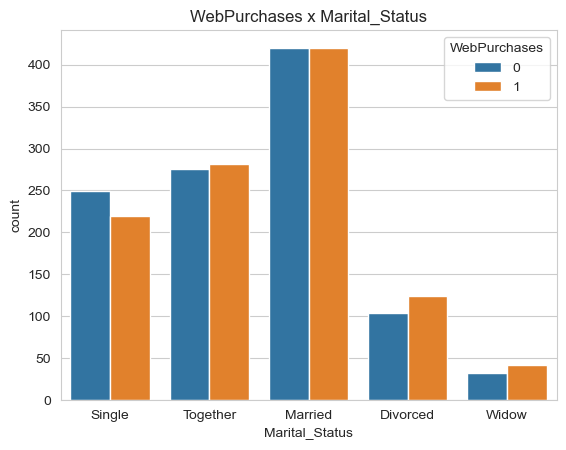

In [124]:
#Seu código aqui
sns.countplot(x='Marital_Status', hue='WebPurchases', data=df)
plt.title('WebPurchases x Marital_Status')
plt.show()

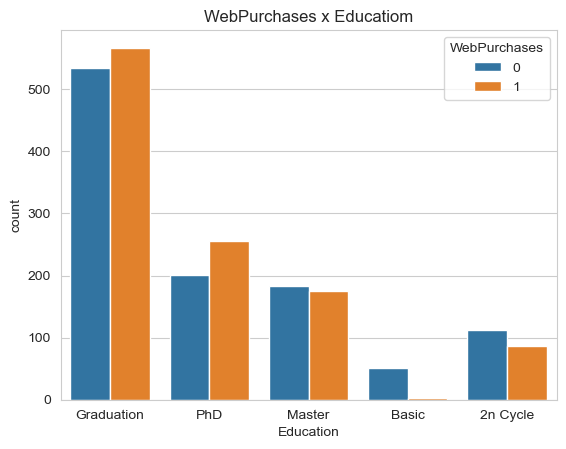

In [125]:
#Seu código aqui
sns.countplot(x='Education', hue='WebPurchases', data=df)
plt.title('WebPurchases x Educatiom')
plt.show()

# ETAPA 2:
**Pré-processamento**

**Análise Correlação:** Verifique a correlação entre as váriaveis e análise se há espaço para retirar váriaveis que não te parecem importantes.

**Codificação de Variáveis Categóricas:** Transformar variáveis categóricas em um formato que os modelos de machine learning possam interpretar.


**Separe a base em Y, X e Treino e teste:**: Faça a separação da base.

**Realize a padronização dos dados**: Padronize os dados para garantir eficiência no modelo e eficácia.








In [126]:
# Aplicar o One Hot para a coluna "Education"
df = pd.get_dummies(df, columns=['Education'], prefix='Education', drop_first=True)

In [127]:
# Aplicar o One Hot para a coluna "Marital Status"
df = pd.get_dummies(df, columns=['Marital_Status'], prefix='Marital_Status', drop_first=True)

In [128]:
for column in df.columns:
    if df[column].dtype == 'bool':
        df[column] = df[column].astype(int)
df.dtypes

Year_Birth                   int64
Income                     float64
Kidhome                      int64
Recency                      int64
MntWines                     int64
MntFruits                    int64
MntMeatProducts              int64
MntFishProducts              int64
MntSweetProducts             int64
MntGoldProds                 int64
NumStorePurchases            int64
NumWebVisitsMonth            int64
Complain                     int64
WebPurchases                 int64
Education_Basic              int64
Education_Graduation         int64
Education_Master             int64
Education_PhD                int64
Marital_Status_Married       int64
Marital_Status_Single        int64
Marital_Status_Together      int64
Marital_Status_Widow         int64
dtype: object

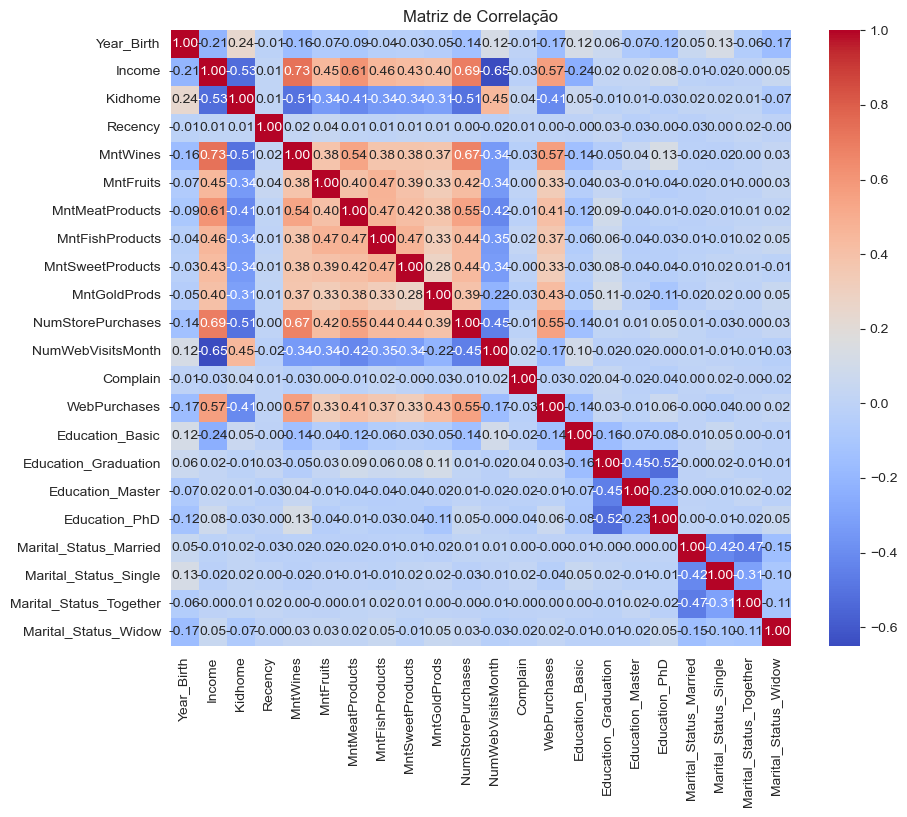

In [129]:
# seu código aqui
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

In [130]:
X = df.drop(columns=['WebPurchases'])
y = df['WebPurchases']

In [131]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [132]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [133]:
pca = PCA(n_components= 20 ) 
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [134]:
# Variância explicada por cada componente
explained_variance = pca.explained_variance_ratio_

# Variância explicada acumulada
cumulative_variance = explained_variance.cumsum()

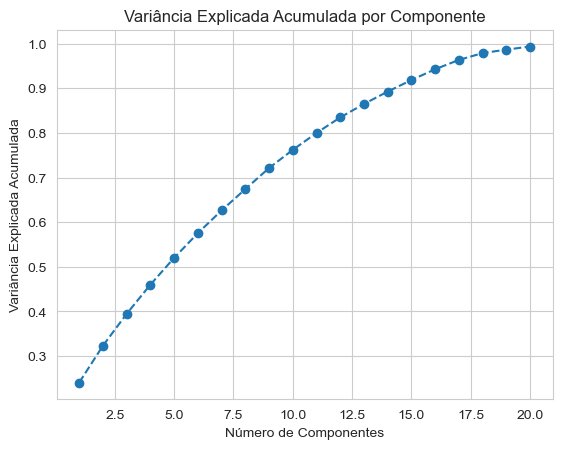

In [135]:
# Plotando a variância explicada acumulada
plt.plot(range(1, 21), cumulative_variance, marker='o', linestyle='--')
plt.title('Variância Explicada Acumulada por Componente')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.grid(True)
plt.show()


# ETAPA 3:

**Modelagem**

Escolha ao menos 2 técnicas de machine learning e rode 2 modelos, afim de identificar qual tem o melhor resultado para essa base. Lembrando que estamos lidando com uma classificação binária.

In [136]:
# seu código aqui - RandomForest
rf_model = RandomForestClassifier(random_state=42)

In [137]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [138]:
# Fazendo previsões no conjunto de teste
y_pred = rf_model.predict(X_test)

In [139]:
# Regressao Logistica
from sklearn.linear_model import LogisticRegression

In [140]:
logistic_vendas = LogisticRegression(random_state = 0)

In [141]:
logistic_vendas.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [142]:
logistic_vendas.intercept_

array([-0.05030922])

In [143]:
logistic_vendas.coef_

array([[ 0.88038631, -0.13567142,  0.12876529, -0.08446456, -0.13136183,
        -0.03338445, -0.21855229,  0.11812375, -0.09419411,  0.45648782,
         1.01782204, -0.28720338,  0.60257989,  0.29104386, -0.19278647,
         0.10703274, -0.43903612, -0.04038284,  1.82142554,  0.16698385]])

In [144]:
previsoes = logistic_vendas.predict(X_train)

# ETAPA 4:

**Avaliação**

Avalie os resultados encontrados nos dois modelos e identifique qual te pareceu realizar melhor as previsões.

Utilize além das métricas padrões a matriz de confusão.

In [145]:
# Avaliando o modelo Random Forest
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação Random Forest:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.89
Relatório de Classificação Random Forest:
               precision    recall  f1-score   support

           0       0.91      0.84      0.88       206
           1       0.87      0.93      0.90       228

    accuracy                           0.89       434
   macro avg       0.89      0.89      0.89       434
weighted avg       0.89      0.89      0.89       434

Matriz de Confusão:
 [[174  32]
 [ 17 211]]


In [146]:
# Avaliando o modelo Regressão Logistica
relatorio = classification_report(y_train, previsoes)
print("Relatório de Classificação Regresão Logistica:")
print(relatorio)

Relatório de Classificação Regresão Logistica:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       875
           1       0.86      0.88      0.87       859

    accuracy                           0.87      1734
   macro avg       0.87      0.87      0.87      1734
weighted avg       0.87      0.87      0.87      1734



Os dois modelos, Regressão Logística e Random Forest, tiveram resultados bem próximos. A acurácia ficou em 86% para a Regressão Logística e 87% para o Random Forest. Ao analisar especificamente a previsão de clientes que compram no site (classe 1), o Random Forest apresentou precisão de 83%, recall de 93% e F1-score de 88%. Já a Regressão Logística teve precisão de 86%, recall de 87% e F1-score de 86%. Com base nesses resultados, o Random Forest se destacou um pouco mais, principalmente por conseguir identificar melhor os clientes que realmente compram. Mesmo assim, ainda há melhorias a serem feitas, como verificar o balanceamento dos dados e ajustar os hiperparâmetros. Também vale a pena testar novamente os modelos após esses ajustes para ver qual apresenta o melhor desempenho final.